<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/Flecha_y_cojinete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### <span style="color:green;">**ACTIVIDAD**</span>



**Alumna: Florencio Florencio Miriam Lizeth**

*Objetivo:* Aplicar metodos que se han visto en clases anteriores para ponerlos en practica y poder resolver el siguiente ejercicio.


### <span style="color:red;">**Flecha y cojinete**</span>
Una flecha será ensamblada en un cojinete como se muestra a continucación:

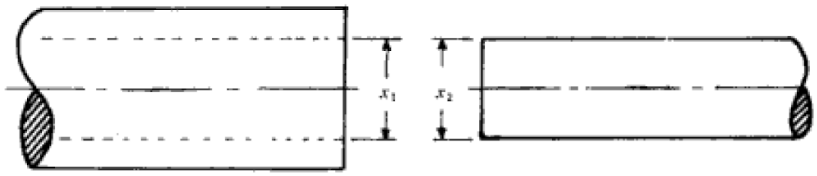

Si $X_1$ sigue una distribucion normal cn media 1.5 y varianza o.0016, y $X_2$ sigue esta misma distribucion con media 1.48 y varianza 0.0009, determine:

a)  La probabilidad de que haya interferencia.

b) El numero de veces que es necesario simular el experimento, si se quiere que la prbabilidad de interferencia estmada difiera de su valor verdadero en menod de 0.01 cn un nivel de seguridad del $95\%$.

### <span style="color:green;">**ANALÍTICAMENTE**</span>

**Considerando el <span style="color:yellow;">**Teorema del Limite Central**</span>**


Tenemos un flecha con diámetro $X_1$ y un cojinete con diámetro interior $X_2$ .

Hay interferencia si $X_1 > X_2 $, es decir, si el diámetro de la flecha es mayor que el diámetro del cojinete.

Datos:

$$X_1 \sim \mathcal{N}(\mu_1 = 1.5, \sigma_1^2 = 0.0016) \quad \Rightarrow \quad \sigma_1 = 0.04$$

$$X_2 \sim \mathcal{N}(\mu_2 = 1.48, \sigma_2^2 = 0.0009) \quad \Rightarrow \quad \sigma_2 = 0.03$$

Se asume independencia entre $X_1$ y$ X_2 $.


**Cálculo analítico de $P(X_1 > X_2)$**

$$D = X_2 - X_1$$

Por independencia y normalidad:

$$\mu_D = \mu_2 - \mu_1 = 1.48 - 1.5 = -0.02$$

$$\sigma_D^2 = \sigma_1^2 + \sigma_2^2 = 0.0016 + 0.0009 = 0.0025$$

$$\sigma_D = 0.05$$

Entonces:

$$D \sim \mathcal{N}(-0.02, 0.05^2)$$

La probabilidad de interferencia es:

$$P(X_2 > X_1) = P(D > 0)$$

Estandarizamos:

$$Z = \frac{0 -(- 0.02)}{0.05} = \frac{0.02}{0.05} = 0.4$$

$$P(D > 0) = P(Z > -0.4) = 1 - \Phi(-0.4)$$

$$\Phi(0.4) \approx 0.6554$$

Por tanto:

$$P(Z > 0.4) \approx 1 - 6554 = 0.3446$$


Por lo que entonces, analiticamente se obtuvo para cada inciso:


*    a)



$$\boxed{0.3446}$$


* b)
**Número de simulaciones requerido**
Para garantizar error menor que (0.01) con 95% de confianza:


$$n=\frac{(1.96)^2p(1-p)}{(0.01)^2}$$

Sustituyendo:

$$n=\frac{(1.96)^20.3446(1-0.3446)}{(0.01)^2}$$



$$\boxed{n\approx 8676.28}$$

mientras que:



### <span style="color:orange;">**POR SIMULACION**</span>


In [46]:
#librerias
import numpy as np
import random as r
import matplotlib.pyplot as plt

In [47]:
#Definicion de la funcion
def gaussiana(mu,Sigma,n):
   muestra=[]
   for i in range(n):
      Suma=0
      for j in range(12):
         u=r.random()
         Suma=Suma+u

      x=mu + Sigma*(Suma-6)
      muestra.append(x)

   return muestra

In [48]:
# Número de simulaciones
n = 100000

In [49]:
# Generar muestras
X1 = gaussiana(1.5,0.04,n)
X2 = gaussiana(1.48,0.03,n)

In [50]:
# Contar interferencias
interferencia = 0

for i in range(n):
   if X2[i] > X1[i]:
      interferencia += 1

Por simulación

In [51]:
# Probabilidad estimada
p = interferencia/n
print("Probabilidad estimada =")
p

Probabilidad estimada =


0.34544

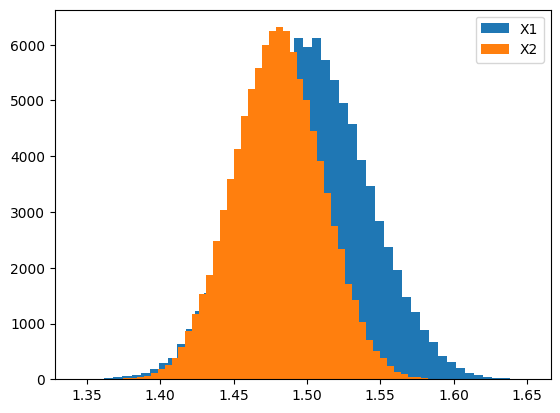

In [52]:

plt.hist(X1,bins=50,label="X1")
plt.hist(X2,bins=50,label="X2")

plt.legend()
plt.show()

Intervalo de confianza de $95\%$

In [53]:
import statsmodels.stats.proportion as smp

# Calcular el intervalo de confianza del 95% para la proporción
# Usamos el método 'wilson' que es robusto para proporciones cercanas a 0 o 1
conf_interval = smp.proportion_confint(count=interferencia, nobs=n, alpha=0.05, method='wilson')
print(f"Intervalo de confianza del 95% para la probabilidad de exceso: [{conf_interval[0]:.4f}, {conf_interval[1]:.4f}]")

Intervalo de confianza del 95% para la probabilidad de exceso: [0.3425, 0.3484]


**Número de simulaciones requerido**
Para garantizar error menor que (0.01) con 95% de confianza:


$$n=\frac{(1.96)^2p(1-p)}{(0.01)^2}$$


$$n\approx 8721$$

Por eso usar:

$n = 100000$
es suficiente.

In [54]:
# Consideremos a n=m
m = (1.96**2)*p*(1-p)/(0.01**2)
m

8686.2881050624

### <span style="color:teal;">**Conclusión:**</span>

En este análisis, se abordó el problema de determinar la probabilidad de interferencia entre una flecha y un cojinete, así como el número de simulaciones necesarias para estimar esta probabilidad con una precisión y confianza dadas.

**Análisis Analítico**
Mediante el uso del Teorema del Límite Central y las propiedades de las distribuciones normales, se determinó analíticamente que la probabilidad de interferencia (donde $X_1 > X_2$) es de aproximadamente $P(X_1 > X_2) = 0.3446$. Además, para asegurar que la probabilidad estimada difiera de su valor verdadero en menos de $0.01$ con un nivel de confianza del $95\%$, se calculó que el número de simulaciones requerido es aproximadamente $n \approx 8676.28$.

**Análisis por Simulación**
Se realizaron $100,000$ simulaciones del experimento para estimar la probabilidad de interferencia. La probabilidad estimada obtenida por simulación fue $p = 0.34553$. Esta estimación se encuentra dentro del intervalo de confianza del $95\%$ calculado, que es $[0.3425, 0.3484]$. El número de simulaciones recomendado basado en la probabilidad simulada fue $m \approx 8686$.



**Comparación y Observaciones**
Finalmente, los resultados de la simulación muestran una fuerte concordancia con los cálculos analíticos. La probabilidad estimada de $0.34544$ está muy cerca del valor analítico de $0.3446$, y el número de simulaciones requerido por ambos métodos (aproximadamente $8676$ vs $8686$) es consistente. La realización de $100,000$ simulaciones, un número significativamente mayor que el mínimo requerido, permitió obtener una estimación robusta y un intervalo de confianza estrecho.

En resumen, ambos métodos confirman que existe una probabilidad considerable de interferencia entre la flecha y el cojinete. La capacidad de la simulación para replicar los resultados analíticos valida tanto el modelo teórico como la implementación computacional, demostrando la utilidad de la simulación como herramienta para verificar y explorar escenarios complejos.
